# Olist E-Commerce Data Analysis

This project analyzes the Brazilian Olist marketplace dataset to understand
customer behavior, delivery performance, and revenue patterns.

The dataset was engineered using SQL in BigQuery and exported for statistical
analysis and machine learning.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/olist-end-to-end-analytics/data/olist_master_orders_features.csv')

## Dataset Overview

This dataset was created using SQL in BigQuery by combining:
orders, payments, reviews, and delivery data.

It contains features required for:
- delivery performance analysis
- customer satisfaction analysis
- payment behavior analysis

In [7]:
df.head()

,order_id,customer_id,order_purchase_timestamp,order_date,delivery_delay_days,delivery_status,review_score,order_value,freight_value,total_order_value,payment_type,payment_installments,payment_value,late_delivery_flag,high_value_order,order_month
0,6e864b3f0ec71031117ad4cf46b7f2a1,9f9d249355f63c5c1216a82b802452c1,2018-04-24 20:15:21 UTC,2018-04-24,-14.0,On Time,5.0,0.85,18.23,19.08,credit_card,1.0,19.08,0,0,4
1,3ee6513ae7ea23bdfab5b9ab60bffcb5,161b6d415e8b3413c6609c70cf405b5a,2018-04-24 11:01:06 UTC,2018-04-24,-10.0,On Time,4.0,0.85,18.23,19.08,boleto,1.0,19.08,0,0,4
2,f1d5c2e6867fa93ceee9ef9b34a53cbf,a790343ca6f3fee08112d678b43aa7c5,2018-08-25 21:20:50 UTC,2018-08-25,-5.0,On Time,5.0,2.20,7.39,9.59,credit_card,1.0,0.31,0,0,8
3,f1d5c2e6867fa93ceee9ef9b34a53cbf,a790343ca6f3fee08112d678b43aa7c5,2018-08-25 21:20:50 UTC,2018-08-25,-5.0,On Time,5.0,2.20,7.39,9.59,voucher,1.0,9.28,0,0,8
4,e8bbc1d69fee39eee4c72cb5c969e39d,184e8e8e48937145eb96c721ef1f0747,2017-09-13 19:13:20 UTC,2017-09-13,-8.0,On Time,5.0,2.29,7.78,10.07,credit_card,1.0,10.07,0,0,9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101326 entries, 0 to 101325
Data columns (total 16 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  101326 non-null  object 
 1   customer_id               101326 non-null  object 
 2   order_purchase_timestamp  101326 non-null  object 
 3   order_date                101326 non-null  object 
 4   delivery_delay_days       101318 non-null  float64
 5   delivery_status           101326 non-null  object 
 6   review_score              100650 non-null  float64
 7   order_value               101326 non-null  float64
 8   freight_value             101326 non-null  float64
 9   total_order_value         101326 non-null  float64
 10  payment_type              101325 non-null  object 
 11  payment_installments      101325 non-null  float64
 12  payment_value             101325 non-null  float64
 13  late_delivery_flag        101326 non-null  i

In [9]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_purchase_timestamp,0
order_date,0
delivery_delay_days,8
delivery_status,0
review_score,676
order_value,0
freight_value,0
total_order_value,0


In [10]:
df.describe()

,delivery_delay_days,review_score,order_value,freight_value,total_order_value,payment_installments,payment_value,late_delivery_flag,high_value_order,order_month
count,101318.000000,100650.000000,101326.000000,101326.000000,101326.000000,101325.000000,101325.000000,101326.000000,101326.000000,101326.000000
mean,-11.897402,4.154029,136.948777,22.820475,159.769252,2.854676,152.897642,0.067258,0.251239,6.030535
std,10.185241,1.286093,209.083681,21.480028,218.835537,2.687409,214.095707,0.250470,0.433728,3.227282
min,-147.000000,1.000000,0.850000,0.000000,9.590000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,-17.000000,4.000000,45.900000,13.860000,61.800000,1.000000,56.780000,0.000000,0.000000,3.000000
50%,-12.000000,5.000000,85.900000,17.200000,104.850000,1.000000,99.940000,0.000000,0.000000,6.000000
75%,-7.000000,5.000000,149.900000,24.050000,175.900000,4.000000,171.120000,0.000000,1.000000,8.000000
max,188.000000,5.000000,13440.000000,1794.960000,13664.080000,24.000000,13664.080000,1.000000,1.000000,12.000000


## Summary Statistics – Key Insights

The dataset contains **~101k delivered orders**, providing a strong sample for statistical analysis and modeling.

### Delivery Performance

The average `delivery_delay_days` is **-11.9 days**, meaning orders are delivered **about 12 days earlier than the estimated delivery date on average**.
However, the range varies widely from **147 days early to 188 days late**, indicating that although most deliveries are early, there are **significant outliers with extreme delays**.

### Customer Satisfaction

The average `review_score` is **4.15 out of 5**, suggesting overall **high customer satisfaction** with the marketplace.
The median review score is **5**, indicating that **most customers leave positive feedback**, though a subset of low ratings lowers the mean slightly.

### Order Value and Revenue Characteristics

The average `total_order_value` is **159.77 BRL**, with a large standard deviation (~218 BRL), showing **high variability in purchase behavior**.
The maximum order value exceeds **13,600 BRL**, indicating the presence of **high-value outlier purchases**.

### Shipping Costs

The average `freight_value` is **22.82 BRL**, which represents roughly **14–15% of the average order value**, suggesting shipping costs are a meaningful component of total transaction cost.

### Payment Behavior

Customers typically pay in **~2.85 installments on average**, while the median is **1 installment**, meaning most purchases are paid upfront but some customers choose installment plans for larger orders.

### Late Deliveries

The `late_delivery_flag` shows that **approximately 6.7% of orders are delivered late**, indicating that the logistics system performs well overall but still has a measurable delay rate that may influence customer reviews.

### High-Value Orders

Around **25% of orders are classified as high-value**, based on the upper quartile of total order value.
This segment represents **important revenue-driving customers**, making it a potential focus for targeted marketing strategies.

---

### Analytical Implications

These descriptive statistics highlight several analytical directions for further investigation:

* Whether **late deliveries significantly reduce customer review scores**
* Whether **payment installment behavior correlates with higher order values**
* Whether **high-value orders are associated with different delivery or review patterns**

These questions will be formally tested using **inferential statistics and hypothesis testing in the next stage of the analysis**.


## Distribution of Customer Review Scores

Customer review scores range from **1 (lowest) to 5 (highest)**.
Understanding the distribution helps determine overall customer satisfaction and whether ratings are skewed toward positive or negative feedback.

A heavily skewed distribution toward higher scores would indicate that most customers are satisfied with their purchases.


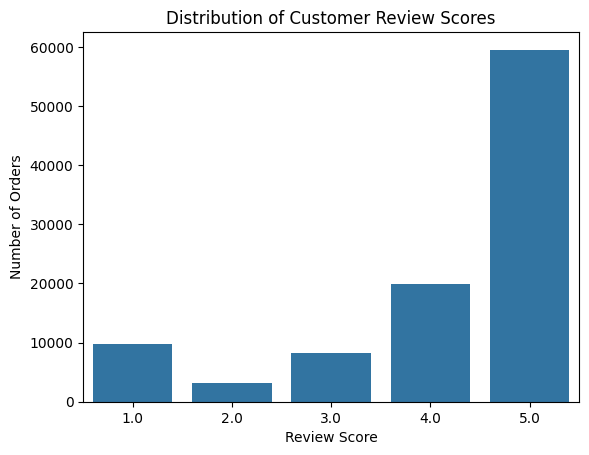

In [13]:
sns.countplot(x='review_score',data=df)
plt.title('Distribution of Customer Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.show()

### Findings

* The distribution is **heavily skewed toward high ratings**.
* **5-star reviews dominate**, indicating very high overall customer satisfaction.
* Ratings **4 and 5 together represent the majority of feedback**.
* Lower ratings (1–3) exist but occur **much less frequently**.
* This suggests that most customers had **positive shopping experiences** on the platform.


## Distribution of Delivery Delay

The `delivery_delay_days` variable measures the difference between the **actual delivery date and the estimated delivery date**.

* Negative values indicate **early deliveries**
* Positive values indicate **late deliveries**

Analyzing this distribution helps understand the performance of the logistics system and whether most deliveries occur before or after the expected date.


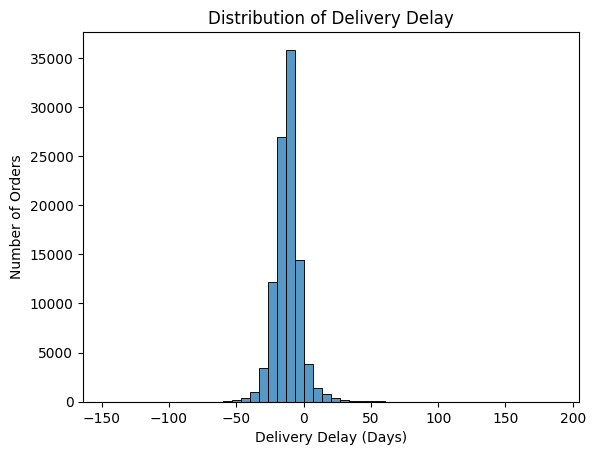

In [17]:
sns.histplot(df['delivery_delay_days'],bins=50)
plt.title('Distribution of Delivery Delay')
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Number of Orders')
plt.show()

### Findings

* Most values are **negative**, meaning orders are typically **delivered earlier than the estimated delivery date**.
* The distribution is centered slightly **below zero**, confirming that early delivery is common.
* A smaller number of orders have **positive delay values**, indicating late deliveries.
* Extreme delays exist but are **rare compared to normal deliveries**.
* Overall, the logistics system appears to **perform efficiently with mostly on-time or early deliveries**.

## Distribution of Order Values

Order values can vary significantly depending on the product category and number of items purchased.

Examining the distribution of `total_order_value` helps identify whether most purchases are small transactions or if a few high-value orders dominate the revenue.

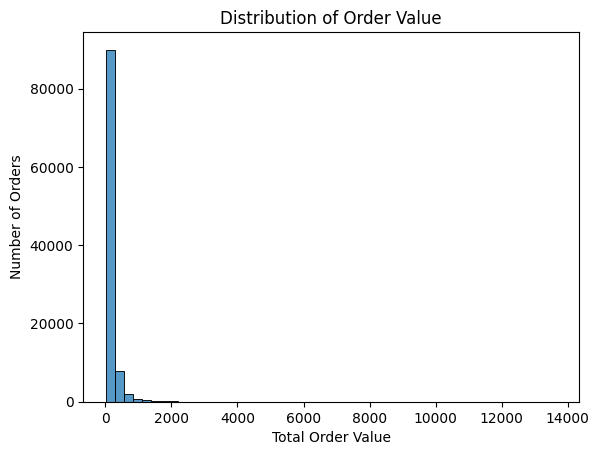

In [18]:
sns.histplot(df['total_order_value'],bins=50)
plt.title('Distribution of Order Value')
plt.xlabel('Total Order Value')
plt.ylabel('Number of Orders')
plt.show()

### Findings

* The distribution is **highly right-skewed**, meaning most orders have **low to moderate values**.
* The majority of purchases occur at **lower price ranges**.
* A small number of orders have **very high values**, creating a long right tail.
* These high-value transactions represent **outliers but contribute significantly to total revenue**.
* This pattern is typical in e-commerce where **many small purchases and few large purchases coexist**.

## Customer Satisfaction vs Delivery Performance

Delivery delays can strongly influence customer satisfaction.
This analysis compares review scores across different delivery statuses to visually examine whether delayed deliveries tend to receive lower ratings.

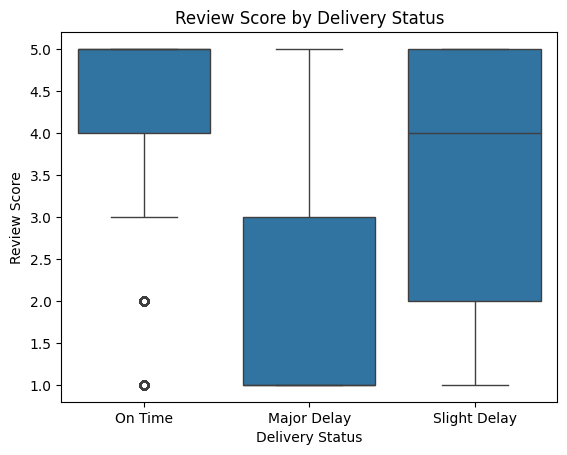

In [19]:
sns.boxplot(x='delivery_status',y='review_score',data=df)
plt.title('Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Review Score')
plt.show()

### Findings

* Orders delivered **on time tend to receive higher review scores**, mostly between **4 and 5**.
* **Major delivery delays are associated with significantly lower ratings**, often between **1 and 3**.
* Slight delays show **mixed customer responses**, with ratings spread across the scale.
* This suggests that **delivery performance strongly influences customer satisfaction**.
* The visual difference between groups indicates that **delivery delays may significantly affect review scores**, which will be tested formally using hypothesis testing.